# Week 9 lab: model interpretation and feature selection

AIE683 Machine Learning.

**Scenario.** You built a model that predicts the median house value of California census
districts. Before anyone uses it, a colleague asks three questions: *Which inputs drive the
predictions? How does the predicted value change when one input changes? Could we get the same
accuracy with fewer inputs?* This lab answers them with permutation importance, partial
dependence / ICE, SHAP, and feature selection, and logs the results to MLflow.

Sections marked **Try it** match the in-class activities on the slides. Their `TODO` cells run
as provided; fill them in during class.

Runtime: about 3 minutes on a laptop.

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "2"  # avoid OpenMP oversubscription (set before importing sklearn)

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.model_selection import KFold, cross_val_score, train_test_split

%matplotlib inline
warnings.simplefilter("ignore", FutureWarning)
RANDOM_STATE = 0

housing = fetch_california_housing(as_frame=True)
X, y = housing.data, housing.target          # target: median house value in $100,000
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)
feature_names = list(X.columns)
X.describe().T[["mean", "min", "max"]].round(2)

,mean,min,max
MedInc,3.87,0.50,15.00
HouseAge,28.64,1.00,52.00
AveRooms,5.43,0.85,141.91
AveBedrms,1.10,0.33,34.07
Population,1425.48,3.00,35682.00
AveOccup,3.07,0.69,1243.33
Latitude,35.63,32.54,41.95
Longitude,-119.57,-124.35,-114.31


## 1. A model worth explaining

In [2]:
gbrt = GradientBoostingRegressor(random_state=RANDOM_STATE).fit(X_train, y_train)
print(f"test R^2 = {gbrt.score(X_test, y_test):.3f}")

test R^2 = 0.781


## 2. Permutation importance

Shuffle one column of the **test** data, measure how much the score drops, repeat. The model is
never refit, so this explains *this* model on *this* data.

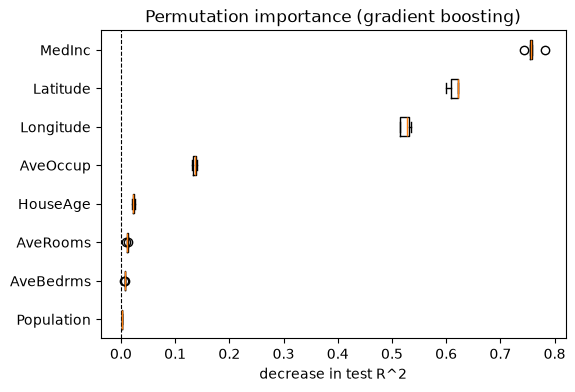

In [3]:
pi = permutation_importance(gbrt, X_test, y_test, n_repeats=5, n_jobs=-1, random_state=RANDOM_STATE)
order = pi.importances_mean.argsort()
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(pi.importances[order].T, orientation="horizontal",
           tick_labels=np.array(feature_names)[order])
ax.axvline(0, color="k", linestyle="--", linewidth=0.8)
ax.set_xlabel("decrease in test R^2")
ax.set_title("Permutation importance (gradient boosting)");

## Try it 1: guess, then measure (10 minutes)

1. **Before running anything**, write down the three features you expect to matter most for
   house prices and store them in `my_guess`.
2. We add two columns that are pure noise: `random_num` (continuous) and `random_cat`
   (3 levels). A random forest is fit on the augmented data (provided).
3. Compute permutation importance of the forest on (a) 3000 training rows and (b) the test set.
4. Compare with the forest's impurity-based `feature_importances_`. Which method gives the
   random columns credit? Why does the training-set version differ from the test-set version?

In [4]:
# TODO 1: your guess (before looking at any output below)
my_guess = []  # e.g. ["FeatureA", "FeatureB", "FeatureC"]

In [5]:
rng = np.random.RandomState(RANDOM_STATE)
X_rand = X.assign(random_num=rng.normal(size=len(X)), random_cat=rng.randint(3, size=len(X)))
Xr_train, Xr_test = X_rand.loc[X_train.index], X_rand.loc[X_test.index]
rf = RandomForestRegressor(n_estimators=60, n_jobs=-1, random_state=RANDOM_STATE).fit(Xr_train, y_train)
impurity = pd.Series(rf.feature_importances_, index=Xr_train.columns)
print(f"forest train R^2 {rf.score(Xr_train, y_train):.3f}, test R^2 {rf.score(Xr_test, y_test):.3f}")

forest train R^2 0.971, test R^2 0.791


In [6]:
# TODO 2: permutation importance of `rf` on 3000 training rows and on the test set.
# Use permutation_importance(..., n_repeats=5, n_jobs=-1, random_state=RANDOM_STATE)
# and keep the `.importances_mean` arrays.
perm_train = None
perm_test = None

In [7]:
if perm_train is None or perm_test is None:
    print("Fill in TODO 2 to see the comparison. Impurity-based importances:")
    display(impurity.sort_values(ascending=False).round(3))
else:
    comparison = pd.DataFrame({"impurity": impurity, "perm_train": perm_train,
                               "perm_test": perm_test}).sort_values("perm_test", ascending=False)
    display(comparison.round(3))
    top3 = list(comparison.index[:3])
    print("your guess:", my_guess, "| measured top 3 (test):", top3)

Fill in TODO 2 to see the comparison. Impurity-based importances:


MedInc        0.528
AveOccup      0.133
Latitude      0.081
Longitude     0.080
HouseAge      0.055
AveRooms      0.046
Population    0.028
AveBedrms     0.028
random_num    0.018
random_cat    0.004
dtype: float64

## 3. Partial dependence and ICE

`kind="both"` overlays individual conditional expectation (ICE) curves, one per district, on the
average (the PDP). `centered=True` anchors every curve at the left edge so that differences in
*shape* become visible.

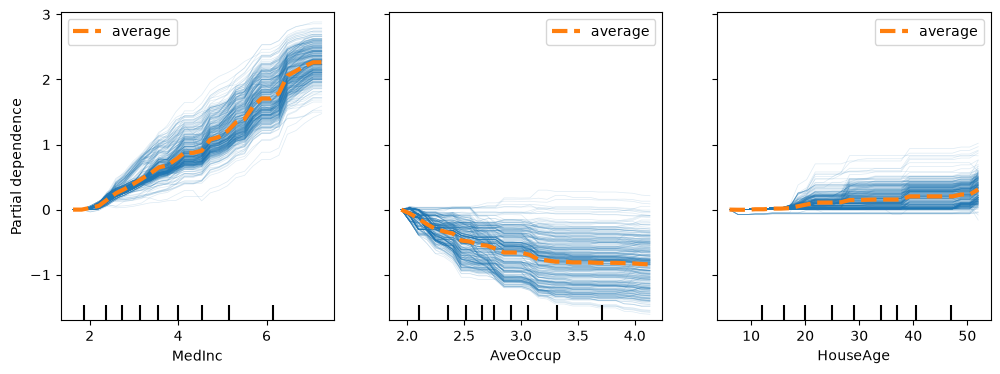

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
PartialDependenceDisplay.from_estimator(
    gbrt, X_train.sample(400, random_state=RANDOM_STATE), ["MedInc", "AveOccup", "HouseAge"],
    kind="both", centered=True, grid_resolution=30, random_state=RANDOM_STATE, ax=ax,
    ice_lines_kw={"alpha": 0.15}, pd_line_kw={"color": "tab:orange", "linewidth": 3});

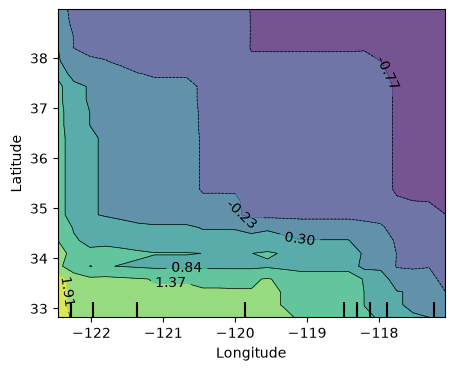

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))
PartialDependenceDisplay.from_estimator(gbrt, X_train, [("Longitude", "Latitude")],
                                        grid_resolution=25, ax=ax);

## 4. SHAP

`TreeExplainer` computes exact SHAP values for tree ensembles. For every district, the base
value plus the SHAP values of its features equals the model's prediction.

additivity holds: True


/Users/hemekci/Desktop/Hacettepe/AIE683-Machine-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


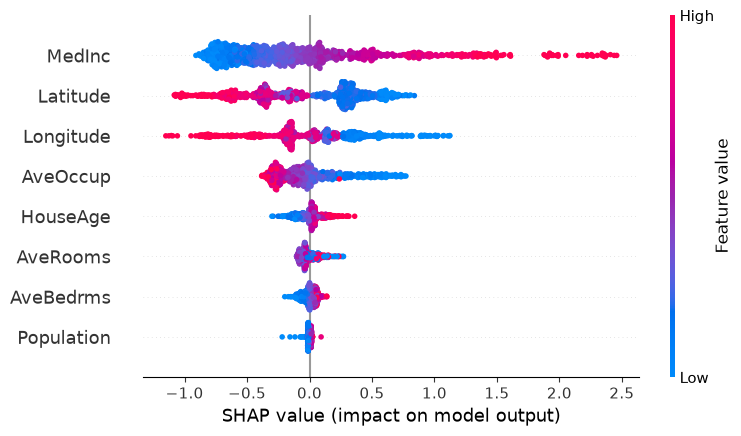

In [10]:
import shap

explainer = shap.TreeExplainer(gbrt)
X_shap = X_test.sample(1000, random_state=RANDOM_STATE)
sv = explainer(X_shap)
print("additivity holds:", np.allclose(sv.base_values + sv.values.sum(axis=1), gbrt.predict(X_shap)))
shap.plots.beeswarm(sv)

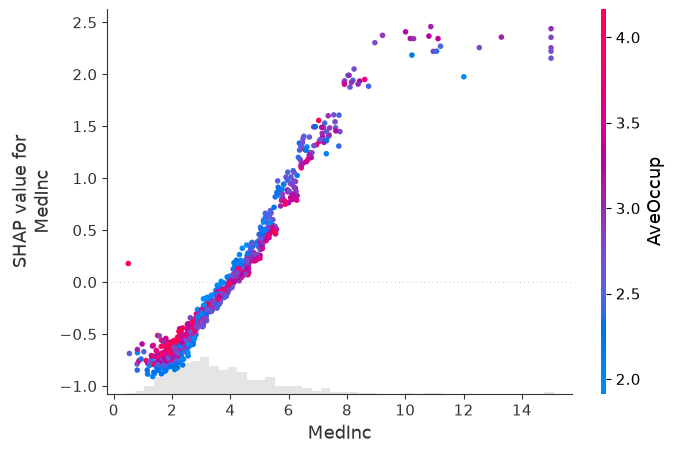

In [11]:
shap.plots.scatter(sv[:, "MedInc"], color=sv[:, "AveOccup"])

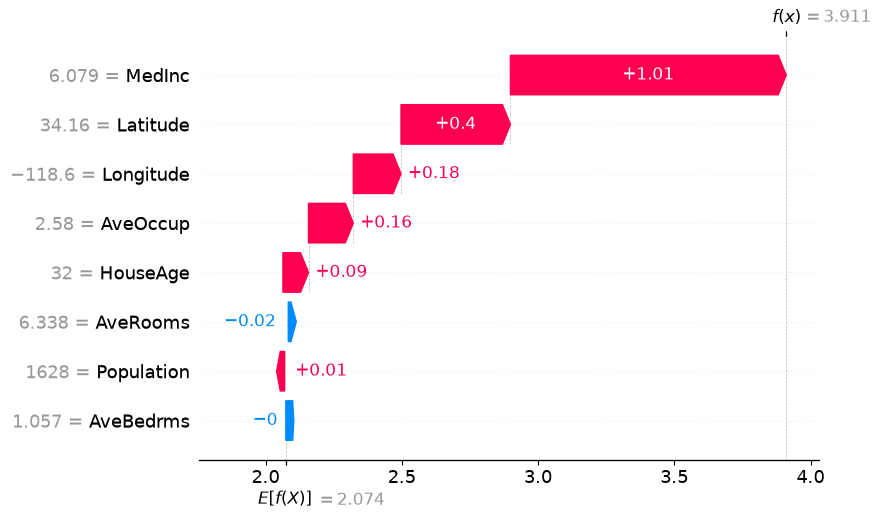

In [12]:
# local explanation for one district
shap.plots.waterfall(sv[0])

## 5. Feature selection

We append five pure-noise columns so that a selection method has something to remove. Every
selector sits **inside** a pipeline, so it is refit on each training fold.

In [13]:
from sklearn.feature_selection import (RFECV, SelectFromModel, SelectKBest,
                                       SequentialFeatureSelector, f_regression)
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(RANDOM_STATE)
noise = pd.DataFrame(rng.normal(size=(len(X), 5)), columns=[f"noise_{i}" for i in range(5)],
                     index=X.index)
Xn = pd.concat([X, noise], axis=1)
Xn_train, Xn_test = Xn.loc[X_train.index], Xn.loc[X_test.index]
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

selectors = {
    "all_features": "passthrough",
    "kbest_f_k6": SelectKBest(f_regression, k=6),
    "lassocv": SelectFromModel(LassoCV(cv=cv), threshold=1e-5),
    "rfecv_lr": RFECV(LinearRegression(), cv=cv),
    "sfs_forward": SequentialFeatureSelector(LinearRegression(), tol=1e-3, cv=cv),
}
pipelines = {name: make_pipeline(StandardScaler(), sel, RidgeCV()) for name, sel in selectors.items()}

rows = []
for name, pipe in pipelines.items():
    score = cross_val_score(pipe, Xn_train, y_train, cv=cv).mean()
    kept = pipe.fit(Xn_train, y_train)[:-1].get_feature_names_out()
    rows.append({"pipeline": name, "cv_r2": score, "n_features": len(kept), "kept": ", ".join(kept)})
selection_table = pd.DataFrame(rows).set_index("pipeline")
selection_table.round(3)

,cv_r2,n_features,kept
pipeline,,,
all_features,0.606,13,"MedInc, HouseAge, AveRooms, AveBedrms, Populat..."
kbest_f_k6,0.603,6,"MedInc, HouseAge, AveRooms, AveBedrms, Latitud..."
lassocv,0.606,10,"MedInc, HouseAge, AveRooms, AveBedrms, Populat..."
rfecv_lr,0.602,7,"MedInc, HouseAge, AveRooms, AveBedrms, AveOccu..."
sfs_forward,0.606,6,"MedInc, HouseAge, AveRooms, AveBedrms, Latitud..."


## Try it 2: find the leak (10 minutes)

The data below are **pure noise**: 100 samples, 5000 random features, random binary labels. No
model can beat 50% accuracy on new data. The provided code nevertheless reports a high
cross-validated accuracy.

1. Explain in one sentence why the provided estimate is wrong.
2. Build `honest_pipe`, a pipeline in which the selection is refit inside every CV fold, and
   report its cross-validated accuracy.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

rng = np.random.RandomState(42)
X_noise = rng.normal(size=(100, 5000))
y_noise = rng.randint(2, size=100)
cv_clf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

# leaky: select the 20 "best" features using ALL labels, then cross-validate
X_selected = SelectKBest(k=20).fit_transform(X_noise, y_noise)
leaky = cross_val_score(LogisticRegression(), X_selected, y_noise, cv=cv_clf).mean()
print(f"leaky CV accuracy: {leaky:.2f}")

leaky CV accuracy: 0.85


In [15]:
# TODO 3: selection inside the pipeline
honest_pipe = None  # make_pipeline(...)

if honest_pipe is not None:
    honest = cross_val_score(honest_pipe, X_noise, y_noise, cv=cv_clf).mean()
    print(f"honest CV accuracy: {honest:.2f}")

## Try it 3: feature-budget challenge (15 minutes)

Build a pipeline that uses **at most 3 of the 13 columns** of `Xn` and maximizes 5-fold CV R^2 on
the 5000-row development sample `Xn_dev, y_dev`. Any model and any selection method (manual,
univariate, model-based, sequential) is allowed. Report your CV score; at the end of the
activity we evaluate every team's pipeline **once** on the test set.

Hint: the final step of the pipeline is the model; everything before it must expose
`get_feature_names_out()` so that the checker can count your features.

In [16]:
Xn_dev, y_dev = Xn_train.iloc[:5000], y_train.iloc[:5000]


def check_pipeline(pipe, max_features=3):
    """Report CV R^2 and the features the pipeline keeps."""
    score = cross_val_score(pipe, Xn_dev, y_dev, cv=cv).mean()
    kept = pipe.fit(Xn_dev, y_dev)[:-1].get_feature_names_out()
    status = "OK" if len(kept) <= max_features else f"TOO MANY FEATURES ({len(kept)})"
    print(f"CV R^2 {score:.3f} | {len(kept)} features: {list(kept)} | {status}")
    return score

In [17]:
# TODO 4: your pipeline, e.g. make_pipeline(<selector>, <model>)
my_pipeline = None

if my_pipeline is not None:
    check_pipeline(my_pipeline)

## 6. Logging interpretation artifacts to MLflow

For each candidate model we log the test score, the permutation importances (table and plot) and,
for tree models, a SHAP beeswarm plot. A second experiment stores the feature-selection comparison
from section 5. Open the results with `uv run mlflow ui` from this folder.

In [18]:
import mlflow

mlflow.set_experiment("week09-interpretation")

candidates = {
    "ridge": make_pipeline(StandardScaler(), RidgeCV()),
    "random_forest": RandomForestRegressor(n_estimators=60, min_samples_leaf=5, n_jobs=-1,
                                           random_state=RANDOM_STATE),
    "gradient_boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

for name, model in candidates.items():
    with mlflow.start_run(run_name=name):
        model.fit(X_train, y_train)
        mlflow.log_param("model", name)
        mlflow.log_metric("test_r2", model.score(X_test, y_test))

        pi = permutation_importance(model, X_test, y_test, n_repeats=5, n_jobs=-1,
                                    random_state=RANDOM_STATE)
        pi_df = pd.DataFrame({"feature": feature_names, "mean": pi.importances_mean,
                              "std": pi.importances_std}).sort_values("mean")
        mlflow.log_table(pi_df, artifact_file="permutation_importance.json")

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.barh(pi_df["feature"], pi_df["mean"], xerr=pi_df["std"])
        ax.set_xlabel("decrease in test R^2")
        ax.set_title(f"Permutation importance: {name}")
        mlflow.log_figure(fig, "permutation_importance.png")
        plt.close(fig)

        if name != "ridge":
            shap.plots.beeswarm(shap.TreeExplainer(model)(X_shap.iloc[:300]), show=False)
            mlflow.log_figure(plt.gcf(), "shap_beeswarm.png")
            plt.close("all")

mlflow.search_runs(experiment_names=["week09-interpretation"], max_results=3,
                   order_by=["attributes.start_time DESC"])[["tags.mlflow.runName", "metrics.test_r2"]]

2026/09/30 00:10:10 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/30 00:10:10 INFO mlflow.store.db.utils: Updating database tables


2026/09/30 00:10:10 INFO mlflow.tracking.fluent: Experiment with name 'week09-interpretation' does not exist. Creating a new experiment.


,tags.mlflow.runName,metrics.test_r2
0,gradient_boosting,0.780900
1,random_forest,0.790552
2,ridge,0.591094


In [19]:
mlflow.set_experiment("week09-feature-selection")
for name, row in selection_table.iterrows():
    with mlflow.start_run(run_name=name):
        mlflow.log_param("selector", name)
        mlflow.log_metrics({"cv_r2": row["cv_r2"], "n_features": row["n_features"]})
        mlflow.log_dict({"selected_features": row["kept"].split(", ")}, "selected_features.json")
print("logged", len(selection_table), "selection runs")

2026/09/30 00:10:17 INFO mlflow.tracking.fluent: Experiment with name 'week09-feature-selection' does not exist. Creating a new experiment.


logged 5 selection runs


## Take-aways

- Impurity-based importances are computed on training data and can credit pure noise; prefer
  permutation importance on held-out data.
- Correlated features share (and can hide) importance under both permutation and SHAP.
- PDPs average; ICE curves reveal heterogeneity that the average hides.
- SHAP values explain the *model's* output, not causal effects in the world.
- Feature selection belongs inside the cross-validation loop.